

# Big Ideas for MC Simulation
### OPIM 5641 - Business Decision Modeling · Module1

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5641-notebooks/blob/main/2_MonteCarlo/Big Ideas for MC Simulation.ipynb)

*Run me top to bottom - **Runtime → Run all**. Data loads from a stable link, so there's nothing to upload.*

# Big Ideas: Monte Carlo Simulation
**Dr. Dave Wanik - OPIM 5641: Business Decision Modeling - University of Connecticut**

------------------------------------------------

Here's the big idea behind Monte Carlo: instead of pretending you know exactly what's going to happen, you admit there's uncertainty, describe it, and then let the computer play out thousands of possible futures so you can see the whole *range* of outcomes - not just a single point guess.

The thing I really want you to take away is that **you're in charge**. As the modeler, *you* decide the assumptions. Sometimes it makes sense to sample from a named distribution (**parametric**), and sometimes it's better to sample straight from whatever data you happen to have (**nonparametric**). Neither one is automatically "right" - it depends on the problem and on what you actually know. Your judgment and domain expertise are what make the model believable to the people who have to act on it.

🔷 **The nugget:** *you* are the modeler - you choose the assumptions. Parametric vs. nonparametric isn't right-or-wrong, it's a judgment call about what you actually know.

# Risk Analysis
Compared to a data science or statistical analysis, MC is useful when you don't have a lot of data or when you want to use your domain knowledge to create something that's 'close enough' to the data you wish you had.

Modeler judgement and domain expertise are ESSENTIAL to building something people can relate to.

Here's an example of a Monte Carlo simulation - the growth of your retirement savings!

<center>

![stock prices](https://miro.medium.com/max/837/1*h4IddWuCwtp1oYOHSczMKQ.png)

</center>

Imagine X axis is time and Y axis is the growth of your portfolio.

People do this all the time in finance. Imagine you have 100K, you contribute 10K per year and the stock market grows at an average of 7%... how much money will you have in 30 years?

If the stock market grew at a constant rate this would be a really boring to solve. You could run 1,000,000 simulations and you would get the same answer 1,000,000 times.

But if you had a distribution, you could do something amazing - you could incorporate uncertainty and show (probabilistically) how much money you will make in the future.

* https://www.macrotrends.net/2526/sp-500-historical-annual-returns

We can hack this table and play with different time horizons to grow our retirement savings - and estimate how much money we will have (average, median, percentiles like 10/90, 1/99, min/max).

## Percentiles
As a refresher, here are percentiles and sd from normal distribution.

![normal dist and percentiles](https://upload.wikimedia.org/wikipedia/commons/5/5c/PR_and_NCE.gif)

# Parametric methods: distributions!

If you google 'Monte Carlo simulation python' you will find tons of cool examples of MC applied to different business and engineering problems.

![comparison of distributions](https://miro.medium.com/max/700/1*cr9_-ts4vqVBOttf-EVuQQ.png)

There are HUNDREDS of distributions that you can choose from. This is a handy reference:
* https://www.bmc.com/blogs/numpy-statistical-functions/

If you can dream it, `numpy` probably has what you are looking for.

# Nonparametric
Want to just sample from whatever data you have available? This is fine, too!

It's nonparametric because you are not specifying the distribution.

You can sample WITH or WITHOUT replacement. Sampling with replacement means you can technically pull the same observation more than once in a sample. Sampling without replacement means that once it's picked, you can't pick it again.

* https://www.statisticshowto.com/sampling-with-replacement-without/

# Go try it!
Let's see if we can use a parametric and nonparametric approach to solving the retirement example.

You are welcome to review the intro to distributions to refresh on some common discrete and continuous probability distributions.

We also have nice examples on:
* cell phones (parametric)
* health claims (parametric with a time component)
* Spotify subscriptions (nonparametric with a time component)

In [ ]:
# https://drive.google.com/file/d/1jdiN3xQF1DhuHaaO4ekZN64aR22_4kxi/view?usp=sharing
!gdown 1jdiN3xQF1DhuHaaO4ekZN64aR22_4kxi

Downloading...
From: https://drive.google.com/uc?id=1jdiN3xQF1DhuHaaO4ekZN64aR22_4kxi
To: /content/S_P_returns.csv
100% 4.76k/4.76k [00:00<00:00, 16.0MB/s]


In [ ]:
# import modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# read the data
df = pd.read_csv('S_P_returns.csv')
df

,Year,Closing price,year open,year high,year high.1,year close,percChange
0,2022,"4,573.28","4,796.56","4,796.56","4,326.51","4,589.38",-3.71%
1,2021,"4,273.41","3,700.65","4,793.06","3,700.65","4,766.18",26.89%
2,2020,"3,217.86","3,257.85","3,756.07","2,237.40","3,756.07",16.26%
3,2019,"2,913.36","2,510.03","3,240.02","2,447.89","3,230.78",28.88%
4,2018,"2,746.21","2,695.81","2,930.75","2,351.10","2,506.85",-6.24%
...,...,...,...,...,...,...,...
90,1932,6.92,7.82,9.31,4.4,6.89,-15.15%
91,1931,13.66,15.85,18.17,7.72,8.12,-47.07%
92,1930,21,21.18,25.92,14.44,15.34,-28.48%
93,1929,26.19,24.81,31.86,17.66,21.45,-11.91%


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95 entries, 0 to 94
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Year           95 non-null     int64 
 1   Closing price  95 non-null     object
 2   year open      95 non-null     object
 3   year high      95 non-null     object
 4   year high.1    95 non-null     object
 5   year close     95 non-null     object
 6   percChange     95 non-null     object
dtypes: int64(1), object(6)
memory usage: 5.3+ KB


We can tell that the data seems mostly OK - except the thing we need! `percChange` is a string... we need to make it a numeric.

In [ ]:
# df['percChange'] = pd.to_numeric(df['percChange'], errors='coerce')
# df.head()

OOPS! You can't coerce while there are string characters (like , $ or %).

Comment it out and try to substitute:
* https://stackoverflow.com/questions/38516481/trying-to-remove-commas-and-dollars-signs-with-pandas-in-python/46430853

In [ ]:
df['percChange'] = df['percChange'].str.replace('%', '')
df.head() # now you can check your work!

,Year,Closing price,year open,year high,year high.1,year close,percChange
0,2022,"4,573.28","4,796.56","4,796.56","4,326.51","4,589.38",-3.71
1,2021,"4,273.41","3,700.65","4,793.06","3,700.65","4,766.18",26.89
2,2020,"3,217.86","3,257.85","3,756.07","2,237.40","3,756.07",16.26
3,2019,"2,913.36","2,510.03","3,240.02","2,447.89","3,230.78",28.88
4,2018,"2,746.21","2,695.81","2,930.75","2,351.10","2,506.85",-6.24


Now there aren't any funky non-numeric characters so you can model.

In [ ]:
# convert to numeric and analyze
df['percChange'] = pd.to_numeric(df['percChange'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95 entries, 0 to 94
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Year           95 non-null     int64  
 1   Closing price  95 non-null     object 
 2   year open      95 non-null     object 
 3   year high      95 non-null     object 
 4   year high.1    95 non-null     object 
 5   year close     95 non-null     object 
 6   percChange     95 non-null     float64
dtypes: float64(1), int64(1), object(5)
memory usage: 5.3+ KB


Let's explore our newfound numeric data.

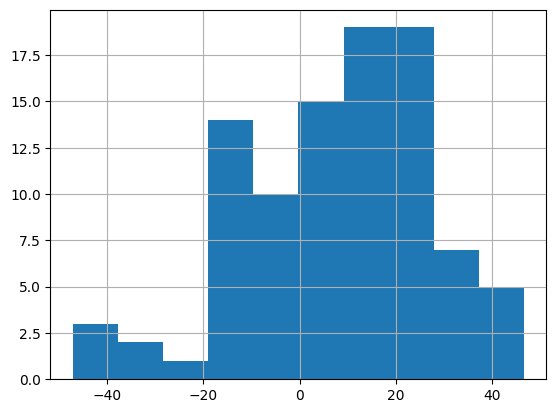

In [ ]:
df['percChange'].hist()
plt.show()

Let's go looking at the stats.

In [ ]:
# interpret this!
df['percChange'].describe()

count    95.000000
mean      7.857263
std      19.007632
min     -47.070000
25%      -5.695000
50%      10.790000
75%      21.020000
max      46.590000
Name: percChange, dtype: float64

On your own - try to sample with and without replacement!

In [ ]:
# how many samples do we need? 30 for 30 years (with or without replacement)
# year 1
initialMoney = 100000
contrib = 10000
rate = 1.03
savings = (initialMoney + contrib)*rate
savings

113300.0

In [ ]:
# year 2
initialMoney = savings
contrib = 10000
rate = 1.03
savings = (initialMoney + contrib)*rate
savings

126999.0

Try to save your results to a .csv so you can email it to a friend!

## Get it right once...

Run it for 30 years one time.

In [ ]:
range(3)

range(0, 3)

In [ ]:
for a in range(30):
  print(a)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29


In [ ]:
tmp = ['red', 'green', 'blue']
for a in tmp:
  print(a)

red
green
blue


In [ ]:
# # check your work
# initalMoney = 100000
# contrib = 10000
# rate = np.random.normal(loc=0.078,scale=0.19,size=1)
# print(1+rate)
# savings = (initialMoney + contrib)*(rate) # update portfolio balance
# print('This is how much money I have at end of year:', savings)

In [ ]:
initialMoney = 100000 # specify initial investment
for a in np.arange(0,30,1):
  print('Year:', a) # print iteration
  contrib = 10000 # annual contributio amount, $
  # rate = 1.03 # growth rate (can be negative) %, 1.03 means 3% growth
  rate = np.random.normal(loc=7.8,scale=19,size=1)
  savings = (initialMoney + contrib)*(1+rate/100) # update portfolio balance
  print('Current Balance at end of Year:', str(a), savings) # print balance
  initialMoney = savings # update variable for next year

Year: 0
Current Balance at end of Year: 0 [117627.66271574]
Year: 1
Current Balance at end of Year: 1 [128923.92903966]
Year: 2
Current Balance at end of Year: 2 [188782.47843159]
Year: 3
Current Balance at end of Year: 3 [229185.3264741]
Year: 4
Current Balance at end of Year: 4 [228022.04554856]
Year: 5
Current Balance at end of Year: 5 [279038.64518818]
Year: 6
Current Balance at end of Year: 6 [289648.18389536]
Year: 7
Current Balance at end of Year: 7 [365078.19894258]
Year: 8
Current Balance at end of Year: 8 [411370.35576434]
Year: 9
Current Balance at end of Year: 9 [470589.06798606]
Year: 10
Current Balance at end of Year: 10 [486159.15647283]
Year: 11
Current Balance at end of Year: 11 [503188.53139695]
Year: 12
Current Balance at end of Year: 12 [523626.10121317]
Year: 13
Current Balance at end of Year: 13 [621121.6325935]
Year: 14
Current Balance at end of Year: 14 [698362.73768674]
Year: 15
Current Balance at end of Year: 15 [740264.02711381]
Year: 16
Current Balance at en

## Run it 10k times!

Try to run a nested for loop with 10 trials.

In [ ]:
for b in np.arange(0,10000,1): # how many trials? 10 trials.
  print('b: ', b)
  for a in np.arange(0,30,1): # for 30 years of retirement
    print('a: ', a)

Streaming output truncated to the last 5000 lines.
a:  21
a:  22
a:  23
a:  24
a:  25
a:  26
a:  27
a:  28
a:  29
b:  9839
a:  0
a:  1
a:  2
a:  3
a:  4
a:  5
a:  6
a:  7
a:  8
a:  9
a:  10
a:  11
a:  12
a:  13
a:  14
a:  15
a:  16
a:  17
a:  18
a:  19
a:  20
a:  21
a:  22
a:  23
a:  24
a:  25
a:  26
a:  27
a:  28
a:  29
b:  9840
a:  0
a:  1
a:  2
a:  3
a:  4
a:  5
a:  6
a:  7
a:  8
a:  9
a:  10
a:  11
a:  12
a:  13
a:  14
a:  15
a:  16
a:  17
a:  18
a:  19
a:  20
a:  21
a:  22
a:  23
a:  24
a:  25
a:  26
a:  27
a:  28
a:  29
b:  9841
a:  0
a:  1
a:  2
a:  3
a:  4
a:  5
a:  6
a:  7
a:  8
a:  9
a:  10
a:  11
a:  12
a:  13
a:  14
a:  15
a:  16
a:  17
a:  18
a:  19
a:  20
a:  21
a:  22
a:  23
a:  24
a:  25
a:  26
a:  27
a:  28
a:  29
b:  9842
a:  0
a:  1
a:  2
a:  3
a:  4
a:  5
a:  6
a:  7
a:  8
a:  9
a:  10
a:  11
a:  12
a:  13
a:  14
a:  15
a:  16
a:  17
a:  18
a:  19
a:  20
a:  21
a:  22
a:  23
a:  24
a:  25
a:  26
a:  27
a:  28
a:  29
b:  9843
a:  0
a:  1
a:  2
a:  3
a:  4
a:  5
a:  6

Now tell me what my average retirement savings will be! 10k trials for 30 years of growth.

In [ ]:
resultDF = []
for b in np.arange(0,10000,1): # how many trials? 10k trials.
  print('b: ', b)
  savings = 0
  for a in np.arange(0,30,1): # for 30 years of retirement
    #print(a) # print iteration
    contrib = 10000 # annual contributio amount, $
    rate = 1 + np.random.normal(loc=7.857263, scale=19.007632, size=1)/100 # growth rate (can be negative) %, 1.03 means 3% growth
    savings = (savings + contrib)*rate # update portfolio balance
    #print(savings) # print balance
    if a == 29:
      resultDF.append(savings)

In [ ]:
resultDF = []
for b in np.arange(0,10000,1): # how many trials? 10k trials.
  print('b: ', b)
  initialMoney = 100000
  for a in np.arange(0,30,1): # for 30 years of retirement
    #print(a) # print iteration
    contrib = 10000 # annual contributio amount, $
    rate = 1 + np.random.normal(loc=7.857263, scale=19.007632, size=1)/100 # growth rate (can be negative) %, 1.03 means 3% growth
    savings = (initialMoney + contrib)*rate # update portfolio balance
    #print(savings) # print balance
    initialMoney = savings # update variable for next year
    tmp = savings # a variable to keep track of
    if a == 29:
      resultDF.append(tmp)

Streaming output truncated to the last 5000 lines.
b:  5000
b:  5001
b:  5002
b:  5003
b:  5004
b:  5005
b:  5006
b:  5007
b:  5008
b:  5009
b:  5010
b:  5011
b:  5012
b:  5013
b:  5014
b:  5015
b:  5016
b:  5017
b:  5018
b:  5019
b:  5020
b:  5021
b:  5022
b:  5023
b:  5024
b:  5025
b:  5026
b:  5027
b:  5028
b:  5029
b:  5030
b:  5031
b:  5032
b:  5033
b:  5034
b:  5035
b:  5036
b:  5037
b:  5038
b:  5039
b:  5040
b:  5041
b:  5042
b:  5043
b:  5044
b:  5045
b:  5046
b:  5047
b:  5048
b:  5049
b:  5050
b:  5051
b:  5052
b:  5053
b:  5054
b:  5055
b:  5056
b:  5057
b:  5058
b:  5059
b:  5060
b:  5061
b:  5062
b:  5063
b:  5064
b:  5065
b:  5066
b:  5067
b:  5068
b:  5069
b:  5070
b:  5071
b:  5072
b:  5073
b:  5074
b:  5075
b:  5076
b:  5077
b:  5078
b:  5079
b:  5080
b:  5081
b:  5082
b:  5083
b:  5084
b:  5085
b:  5086
b:  5087
b:  5088
b:  5089
b:  5090
b:  5091
b:  5092
b:  5093
b:  5094
b:  5095
b:  5096
b:  5097
b:  5098
b:  5099
b:  5100
b:  5101
b:  5102
b:  5103
b:  5104
b:  

In [ ]:
resultDF

[array([823892.74039823]),
 array([1923156.77226415]),
 array([5691427.75449154]),
 array([1295100.15093886]),
 array([1611257.19853745]),
 array([3493986.64658624]),
 array([911030.61434659]),
 array([1181161.28821153]),
 array([5113298.81027036]),
 array([865075.21958168]),
 array([539518.90297245]),
 array([3473542.27875812]),
 array([3583655.64909095]),
 array([2614005.12085397]),
 array([274360.49209413]),
 array([1019707.6739972]),
 array([741659.39478327]),
 array([623722.68722773]),
 array([5186426.23155515]),
 array([2574323.86059029]),
 array([613859.08518355]),
 array([3137526.6830588]),
 array([4395331.63385948]),
 array([606849.73323547]),
 array([1613174.93783979]),
 array([3799734.67788095]),
 array([6182735.09811854]),
 array([2827399.58572387]),
 array([2558139.81083646]),
 array([1573000.00505602]),
 array([3454352.62701985]),
 array([2585254.25330185]),
 array([2612843.37322687]),
 array([1670380.40276789]),
 array([2210001.75400901]),
 array([1271491.5975601]),
 arr

In [ ]:
# convert to a dataframe
resultDF = pd.DataFrame(resultDF)
resultDF.rename(columns={0:'Savings'}, inplace=True)
resultDF

,Savings
0,8.238927e+05
1,1.923157e+06
2,5.691428e+06
3,1.295100e+06
4,1.611257e+06
...,...
9995,1.441278e+06
9996,7.089982e+05
9997,5.175597e+05
9998,4.273120e+05


# Analysis: Parametric

In [ ]:
resultDF['Savings'].describe()

count    1.000000e+04
mean     2.144577e+06
std      2.025379e+06
min      6.469625e+04
25%      8.941654e+05
50%      1.526917e+06
75%      2.664964e+06
max      2.464597e+07
Name: Savings, dtype: float64

Run some percentiles.

In [ ]:
resultDF.quantile([0, 0.01, 0.025, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.975, 0.99, 1])

,Savings
0.000,6.469625e+04
0.010,2.493085e+05
0.025,3.302842e+05
0.050,4.159436e+05
0.100,5.596204e+05
0.250,8.941654e+05
0.500,1.526917e+06
0.750,2.664964e+06
0.900,4.393814e+06
0.950,5.992046e+06


Make a histogram.

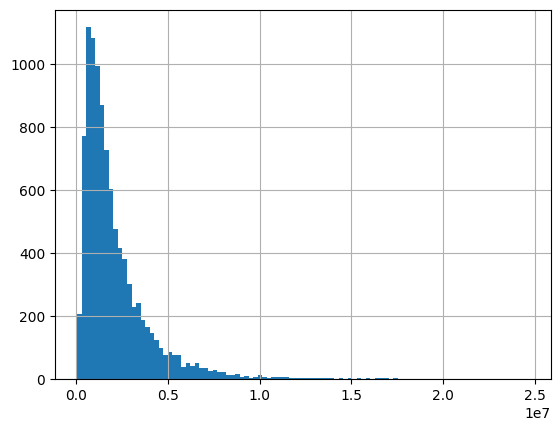

In [ ]:
resultDF['Savings'].hist(bins=100)
plt.show()

# Analysis: Nonparametric
Turns out this one will take a bit longer - why? Probably the sample function. You can try to time your code if you want to confirm.

In [ ]:
# let's try to sample one observation
df['percChange'].sample(n=1)

5    19.42
Name: percChange, dtype: float64

In [ ]:
resultDF = []
for b in np.arange(0,1000,1): # how many trials? 10k trials.
  #print('b: ', b)
  initialMoney = 100000
  for a in np.arange(0,30,1): # for 30 years of retirement
    #print(a) # print iteration
    contrib = 10000*(1+a*0.03) # annual contributio amount, $
    rate = 1 + df['percChange'].sample(n=1)/100 # growth rate (can be negative) %, 1.03 means 3% growth
    rate = np.array(rate) # note: needed to change to numpy array
    #print(rate)
    savings = (initialMoney + contrib)*rate # update portfolio balance
    #print(savings) # print balance
    initialMoney = savings # update variable for next year
    tmp = savings # a variable to keep track of
    if a == 29:
      resultDF.append(tmp)
      #print(tmp)

In [ ]:
# convert to a dataframe
resultDF = pd.DataFrame(resultDF)
resultDF.rename(columns={0:'Savings'}, inplace=True)
resultDF

,Savings
0,1.300832e+06
1,2.903181e+06
2,6.910500e+05
3,2.193958e+06
4,3.985459e+06
...,...
995,1.457742e+06
996,1.582177e+06
997,6.133600e+06
998,9.060766e+06


In [ ]:
resultDF['Savings'].describe()

count    1.000000e+03
mean     2.600176e+06
std      2.663340e+06
min      1.815134e+05
25%      1.127278e+06
50%      1.815640e+06
75%      3.080234e+06
max      2.634134e+07
Name: Savings, dtype: float64

Run some percentiles.

In [ ]:
resultDF.quantile([0, 0.01, 0.025, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.975, 0.99, 1])

,Savings
0.000,1.815134e+05
0.010,2.768586e+05
0.025,4.178059e+05
0.050,5.172320e+05
0.100,7.134073e+05
0.250,1.127278e+06
0.500,1.815640e+06
0.750,3.080234e+06
0.900,5.330909e+06
0.950,6.835647e+06


Make a histogram.

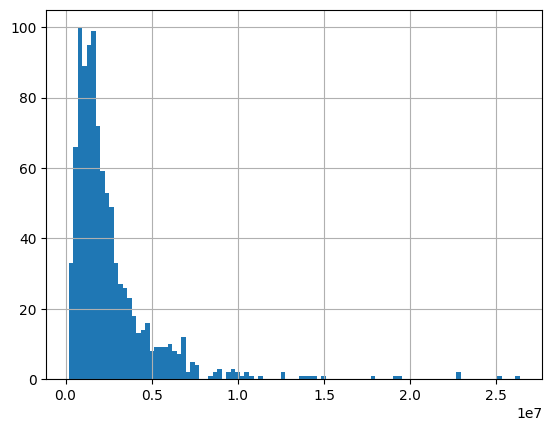

In [ ]:
resultDF['Savings'].hist(bins=100)
plt.show()

# Compare results
Your results may be different due to randomness, but on average, we expect to make
* Parametric: your number goes here
* Nonparametric: your number goes here ;)

... when we retire!

## Bottom line

- Monte Carlo shines when you *don't* have a mountain of data but you *do* have domain knowledge - you build something "close enough" and simulate.
- **Parametric vs. nonparametric is your call** as the modeler: sample from a distribution you assume, or resample from data you already have.
- Run it once and get it right, *then* wrap it in a loop and run it 10,000 times to see the whole distribution of outcomes.
- And remember the exam framing: Monte Carlo tells you what *might* happen under uncertainty; optimization tells you what you *should* do. Different tools, different questions.